## Task 1: Construct Decision Tree models for classification and regression applications
*Suggested Datasets: Pima Indians Diabetes Dataset (Classification) / Boston Housing Dataset (Regression)*


### Subtask 1.1: Data Acquisition and Train-Test Splits for Classification
**Concept:** Import warnings suppression parameters, load the Pima Indians Diabetes dataset, and partition features into training and test validation sets.


In [4]:
import warnings

In [5]:
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [9]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [10]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [11]:
X_pima = pima_df[pima_cols[:-1]]

In [12]:
y_pima = pima_df['Outcome']

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [14]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [15]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


### Subtask 1.2: Constructing the Decision Tree Classifier
**Concept:** Design and train a Decision Tree Classifier, restricting the max depth to prevent overfitting, and evaluate test classification metrics.


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
from sklearn.metrics import accuracy_score, classification_report

In [18]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [19]:
tree_clf.fit(X_train_c, y_train_c)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
clf_preds = tree_clf.predict(X_test_c)

In [21]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [22]:
print("--- Classification Report ---")

--- Classification Report ---


In [23]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



### Subtask 1.3: Visualizing the Trained Decision Tree Structure
**Concept:** Plot and inspect the trained Decision Tree structure using plot_tree to identify node thresholds, Gini impurity levels, and split paths.


In [24]:
import matplotlib.pyplot as plt

In [25]:
from sklearn.tree import plot_tree

In [26]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

[Text(0.5125, 0.9, 'Glucose <= 154.5\ngini = 0.454\nsamples = 614\nvalue = [400, 214]\nclass = No Diabetes'),
 Text(0.275, 0.7, 'BMI <= 27.35\ngini = 0.379\nsamples = 515\nvalue = [384, 131]\nclass = No Diabetes'),
 Text(0.39375, 0.8, 'True  '),
 Text(0.15, 0.5, 'Glucose <= 151.5\ngini = 0.097\nsamples = 137\nvalue = [130, 7]\nclass = No Diabetes'),
 Text(0.1, 0.3, 'BMI <= 9.1\ngini = 0.084\nsamples = 136\nvalue = [130, 6]\nclass = No Diabetes'),
 Text(0.05, 0.1, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = No Diabetes'),
 Text(0.15, 0.1, 'gini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = No Diabetes'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Diabetes'),
 Text(0.4, 0.5, 'Age <= 30.5\ngini = 0.441\nsamples = 378\nvalue = [254, 124]\nclass = No Diabetes'),
 Text(0.3, 0.3, 'Glucose <= 127.5\ngini = 0.332\nsamples = 205\nvalue = [162, 43]\nclass = No Diabetes'),
 Text(0.25, 0.1, 'gini = 0.238\nsamples = 159\nvalue = [137, 22]\nclass = No Diabetes'),
 T

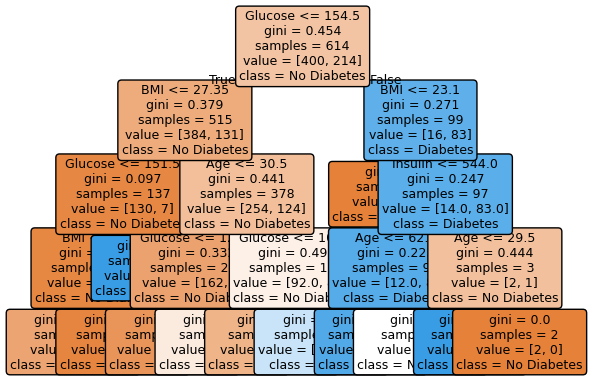

In [27]:
plot_tree(tree_clf, feature_names=pima_cols[:-1], class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True,  fontsize=9)

Text(0.5, 1.0, 'Decision Tree Classifier Structure (Max Depth = 4)_02048')

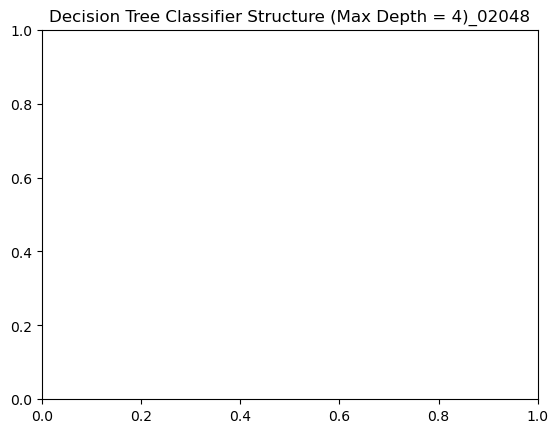

In [28]:
plt.title("Decision Tree Classifier Structure (Max Depth = 4)_02048")


In [29]:
plt.show()

### Subtask 1.4: Visualizing the Trained Decision Tree Structure
**Concept:** Plot and inspect the trained Decision Tree structure using plot_tree to identify node thresholds, Gini impurity levels, and split paths.


In [30]:
from sklearn.tree import DecisionTreeRegressor

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [33]:
boston_df = pd.read_csv(boston_url)

In [34]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [35]:
X_boston = boston_df[boston_features]

In [36]:
y_boston = boston_df['medv']

In [37]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [38]:
scaler_r = StandardScaler()

In [39]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [40]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [41]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [42]:
tree_reg.fit(X_train_r_scaled, y_train_r)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [43]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


### Subtask 1.5: Evaluating Decision Tree Regressor Predictions
**Concept:** Compute continuous evaluation metrics (MSE and R2 Score) for your Decision Tree Regressor and plot actual versus predicted values.


In [44]:
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
import numpy as np

In [46]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [47]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [48]:
rmse_val = np.sqrt(mse_val)

In [49]:
r2_val = r2_score(y_test_r, reg_preds)

In [50]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [51]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [52]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



In [53]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

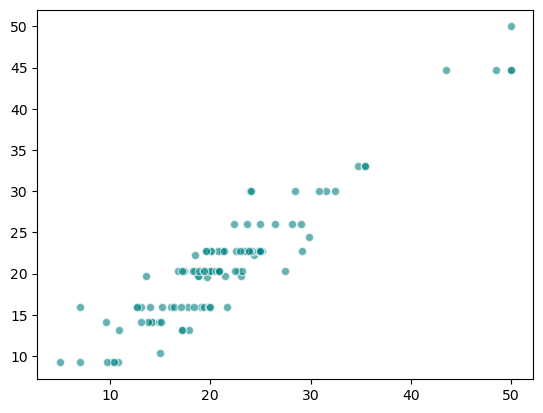

In [54]:
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')

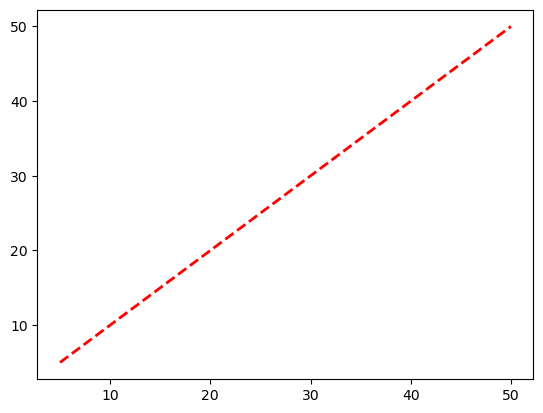

In [55]:
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')

Text(0.5, 1.0, 'Decision Tree Regressor: Actual vs. Predicted_02048')

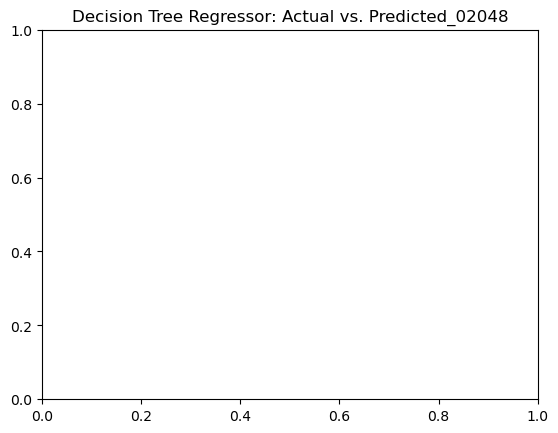

In [56]:
plt.title("Decision Tree Regressor: Actual vs. Predicted_02048")

Text(0.5, 0, 'Actual Home Value (MEDV)')

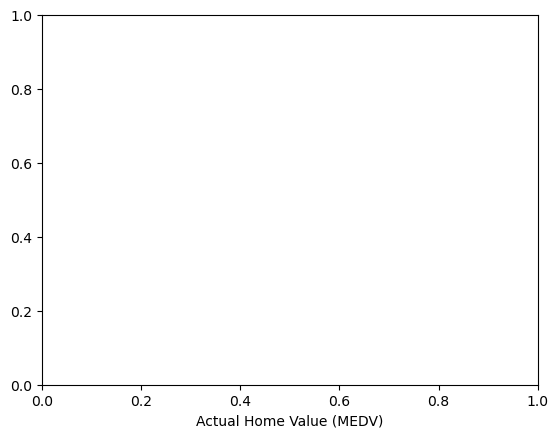

In [57]:
plt.xlabel("Actual Home Value (MEDV)")

Text(0, 0.5, 'Predicted Home Value (MEDV)')

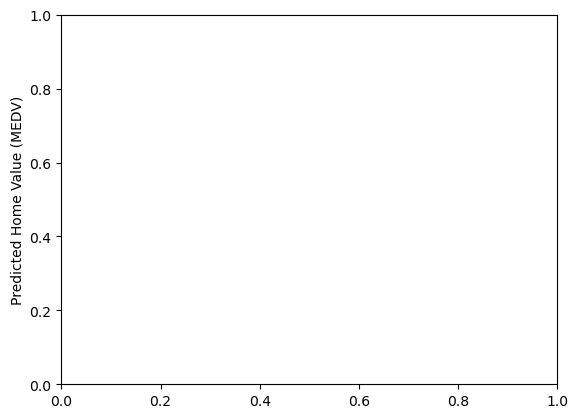

In [58]:
plt.ylabel("Predicted Home Value (MEDV)")

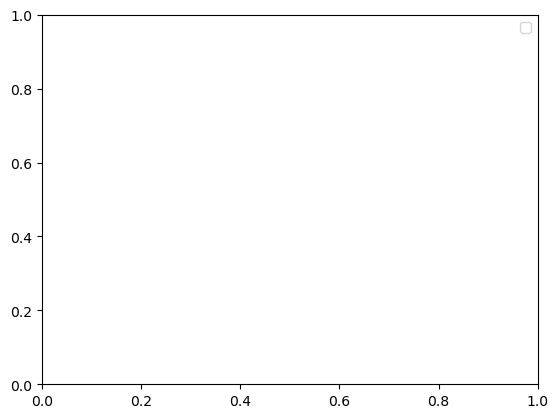

In [59]:
plt.legend()

In [60]:
plt.show()

### Subtask 2.1: Standard Scaling and High-Dimensional Target Map
**Concept:** Import warnings suppression, load the high-dimensional Sonar dataset, map targets ('M'/'R') to binary values, standardize features, and perform a stratified split.


In [61]:
import warnings

In [62]:
import pandas as pd

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [66]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [67]:
sonar_columns = sonar_features + ['Class']

In [68]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [69]:
X_sonar = sonar_df[sonar_features]


In [70]:
y_sonar = sonar_df['Class_numeric']

In [71]:
scaler_sonar = StandardScaler()

In [72]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [73]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [74]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [75]:

print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Implementing a Bagging Classifier
**Concept:** Train a Bagging Classifier using bootstrap aggregation on base Decision Tree estimators to reduce model variance.


In [76]:
from sklearn.ensemble import BaggingClassifier

In [77]:
from sklearn.metrics import accuracy_score

In [78]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [79]:
bagging_model.fit(X_train_s, y_train_s)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [80]:
bagging_preds = bagging_model.predict(X_test_s)

In [81]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [82]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


### Subtask 2.3: Implementing a Random Forest Classifier
**Concept:** Train a Random Forest Classifier to observe how feature subspace selection decorrelates individual trees and controls variance.


In [83]:
from sklearn.ensemble import RandomForestClassifier

In [84]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [85]:
rf_model.fit(X_train_s, y_train_s)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
rf_preds = rf_model.predict(X_test_s)

In [87]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [88]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


### Subtask 2.4: Implementing a Voting Ensemble Classifier
**Concept:** Develop a Voting Classifier (Soft Voting) combining Logistic Regression, SVM, and a Decision Tree to establish consensus decisions.


In [89]:
from sklearn.ensemble import VotingClassifier

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
from sklearn.svm import SVC

In [92]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [93]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [94]:
voting_model.fit(X_train_s, y_train_s)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [95]:
voting_preds = voting_model.predict(X_test_s)

In [96]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [97]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


### Subtask 2.5: Performance Comparison of Ensemble Techniques
**Concept:** Tabulate and plot a bar chart comparing test accuracies across Bagging, Random Forest, and Voting ensemble models.


In [98]:
import matplotlib.pyplot as plt

In [99]:
import seaborn as sns

In [100]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [101]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


In [102]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Test Accuracy (%)', ylabel='Ensemble Technique'>

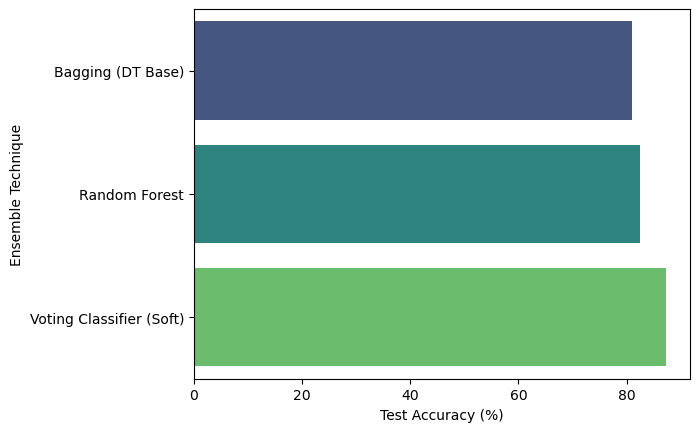

In [103]:
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')

(50.0, 100.0)

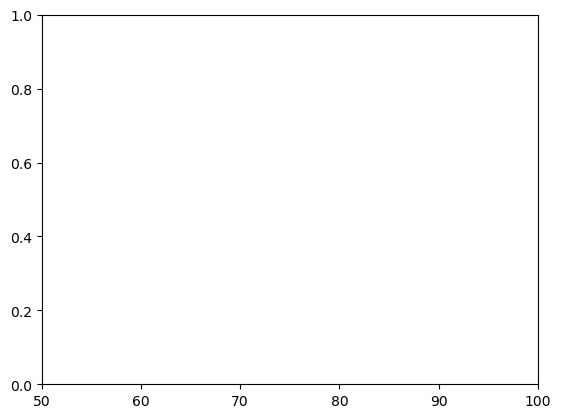

In [104]:
plt.xlim([50, 100])

Text(0.5, 1.0, 'Ensemble Models Accuracy Comparison_02048')

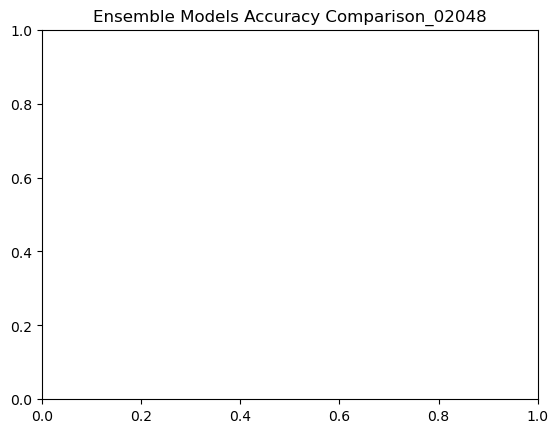

In [105]:
plt.title("Ensemble Models Accuracy Comparison_02048")

In [106]:
plt.show()

## Task 3: Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement
*Continuous Evaluations on Sonar Dataset*


### Subtask 3.1: Implementing the AdaBoost Classifier
**Concept:** Import warnings suppression and train an AdaBoost Classifier to observe how sequential boosting assigns higher weights to misclassified instances.


In [107]:
import warnings

In [108]:
warnings.filterwarnings("ignore")

In [109]:
from sklearn.ensemble import AdaBoostClassifier

In [110]:
from sklearn.metrics import accuracy_score

In [111]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [112]:
adaboost_model.fit(X_train_s, y_train_s)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [113]:
ada_preds = adaboost_model.predict(X_test_s)

In [114]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [115]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


### Subtask 3.2: Implementing the Gradient Boosting Classifier
**Concept:** Train a baseline Gradient Boosting Classifier to observe sequential boosting optimization over loss function gradients.


In [116]:
from sklearn.ensemble import GradientBoostingClassifier

In [117]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [118]:
gb_model.fit(X_train_s, y_train_s)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [119]:
gb_preds = gb_model.predict(X_test_s)

In [120]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [121]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


### Subtask 3.3: Hyperparameter Tuning for Gradient Boosting Classifier
**Concept:** Use GridSearchCV to tune hyperparameters (learning rate, tree count, max depth) of your Gradient Boosting Classifier to optimize model fit.


In [122]:
from sklearn.model_selection import GridSearchCV

In [123]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [124]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [125]:
grid_gb.fit(X_train_s, y_train_s)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [126]:
best_gb = grid_gb.best_estimator_

In [127]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [128]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [129]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}


In [130]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 79.37%


### Subtask 3.4: Master Comparison: Ensemble vs. Boosting Models
**Concept:** Create a comprehensive summary table comparing the test accuracies of all models trained in Tasks 2 and 3.


In [131]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [132]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [133]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


### Subtask 3.5: Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)
**Concept:** Plot and compare the feature importances derived from both the Random Forest and the tuned Gradient Boosting models.


In [134]:
import matplotlib.pyplot as plt

In [135]:
import numpy as np

In [136]:
rf_importances = rf_model.feature_importances_

In [137]:
gb_importances = best_gb.feature_importances_

In [138]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [139]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [140]:
features_list = [f"F_{i}" for i in range(1, 61)]

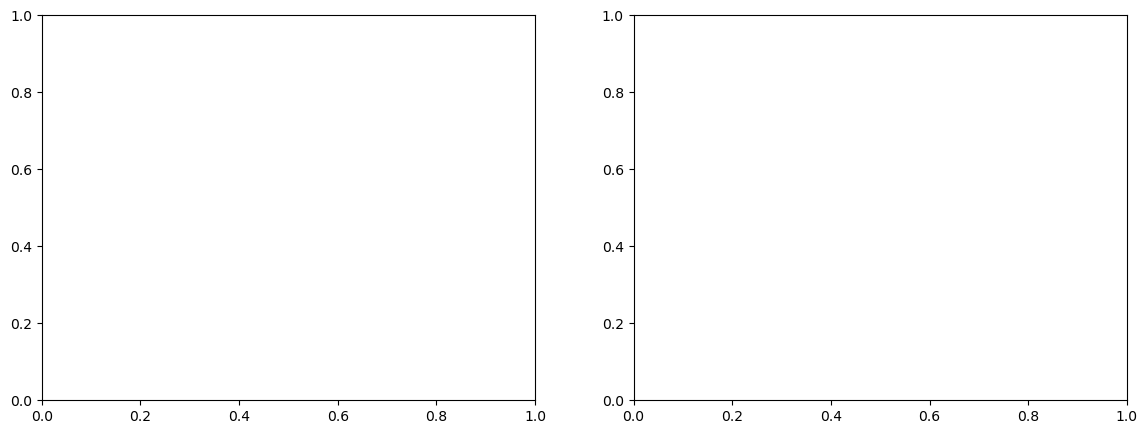

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [142]:
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')

<BarContainer object of 10 artists>

In [143]:
axes[0].set_yticks(range(10))

In [144]:
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])

[Text(0, 0, 'F_1'),
 Text(0, 1, 'F_36'),
 Text(0, 2, 'F_49'),
 Text(0, 3, 'F_52'),
 Text(0, 4, 'F_12'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_48'),
 Text(0, 7, 'F_10'),
 Text(0, 8, 'F_11'),
 Text(0, 9, 'F_9')]

In [145]:
axes[0].set_title("Top 10 Feature Importances: Random Forest")

Text(0.5, 1.0, 'Top 10 Feature Importances: Random Forest')

In [146]:
axes[0].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [147]:
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')

<BarContainer object of 10 artists>

In [148]:
axes[1].set_yticks(range(10))

In [149]:
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])

[Text(0, 0, 'F_10'),
 Text(0, 1, 'F_48'),
 Text(0, 2, 'F_43'),
 Text(0, 3, 'F_17'),
 Text(0, 4, 'F_37'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_4'),
 Text(0, 7, 'F_28'),
 Text(0, 8, 'F_9'),
 Text(0, 9, 'F_11')]

In [150]:
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")

Text(0.5, 1.0, 'Top 10 Feature Importances: Tuned Gradient Boosting')

In [151]:
axes[1].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [152]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [153]:
plt.show()

performance classification titanic dataset

In [154]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = sns.load_dataset("titanic")

df = df[["pclass", "sex", "age", "fare", "survived"]]
df["age"] = df["age"].fillna(df["age"].mean())

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7988826815642458
